In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'sleep-health-and-lifestyle-dataset' dataset.
Dataset downloaded to: /kaggle/input/sleep-health-and-lifestyle-dataset


In [ ]:
import os
import pandas as pd

print(os.listdir(path))

csv_path = os.path.join(path, "Sleep_health_and_lifestyle_dataset.csv")

df = pd.read_csv(csv_path)

['Sleep_health_and_lifestyle_dataset.csv']


Import the Libraries

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)

Dataset Description

In [ ]:
print("First 5 Records")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

First 5 Records


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea



Dataset Shape:
(374, 13)

Column Names:
Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

Data Types:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

Missing Values:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity

Statistical Summary

In [ ]:
df.describe(include="all")

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,155
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,25,NaN,NaN,2
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,130/85,NaN,NaN,Sleep Apnea
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,99,NaN,NaN,78
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,NaN,70.165775,6816.844920,NaN
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,NaN,4.135676,1617.915679,NaN
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,NaN,65.000000,3000.000000,NaN
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,NaN,68.000000,5600.000000,NaN
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,NaN,70.000000,7000.000000,NaN
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,NaN,72.000000,8000.000000,NaN


Check Duplicate Records

In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Duplicate Rows : 0
Dataset Shape After Removing Duplicates:
(374, 13)


Encode Categorical Variables

In [ ]:
df_encoded = df.copy()

encoder = LabelEncoder()

categorical_columns = df_encoded.select_dtypes(include="object").columns

for col in categorical_columns:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

df_encoded.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,1,27,9,6.1,6,42,6,3,11,77,4200,2
1,2,1,28,1,6.2,6,60,8,0,9,75,10000,2
2,3,1,28,1,6.2,6,60,8,0,9,75,10000,2
3,4,1,28,6,5.9,4,30,8,2,22,85,3000,1
4,5,1,28,6,5.9,4,30,8,2,22,85,3000,1


Distribution of Sleep Duration

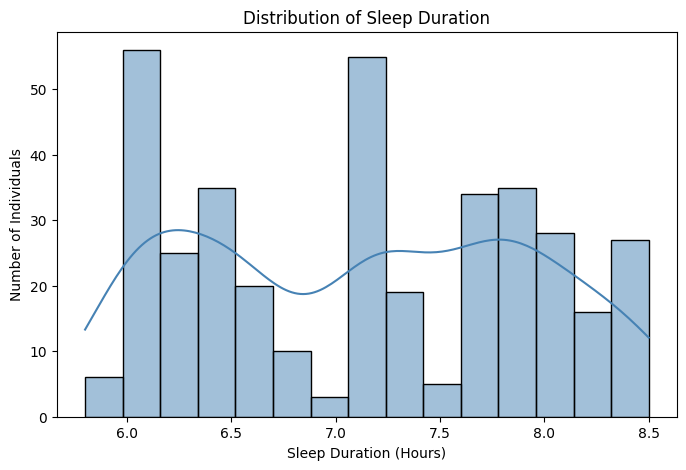

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sleep Duration"], bins=15, kde=True, color="steelblue")

plt.title("Distribution of Sleep Duration")
plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Number of Individuals")

plt.show()

Distribution of Sleep Quality

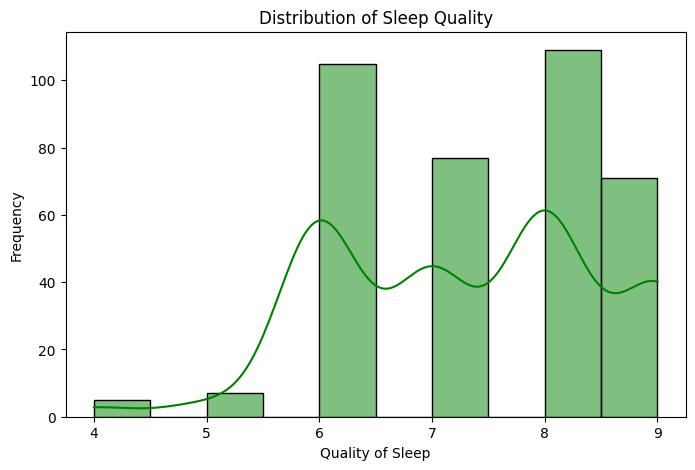

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Quality of Sleep"], bins=10, kde=True, color="green")

plt.title("Distribution of Sleep Quality")
plt.xlabel("Quality of Sleep")
plt.ylabel("Frequency")

plt.show()

Sleep Disorder Distribution

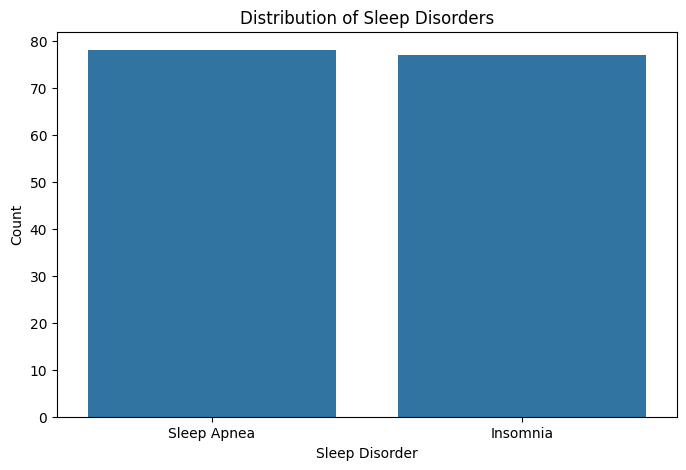

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x="Sleep Disorder", data=df)

plt.title("Distribution of Sleep Disorders")
plt.xlabel("Sleep Disorder")
plt.ylabel("Count")

plt.show()

Gender Distribution

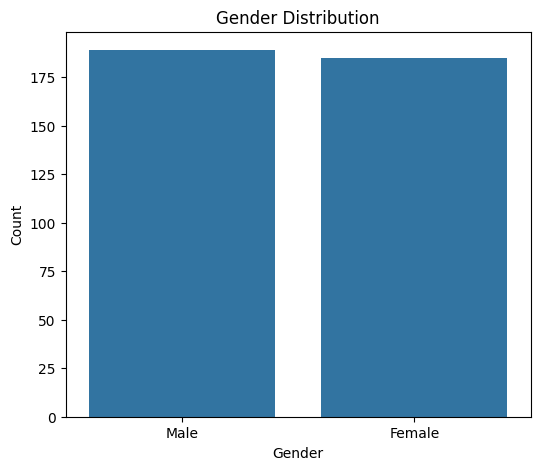

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

Correlation Heatmap

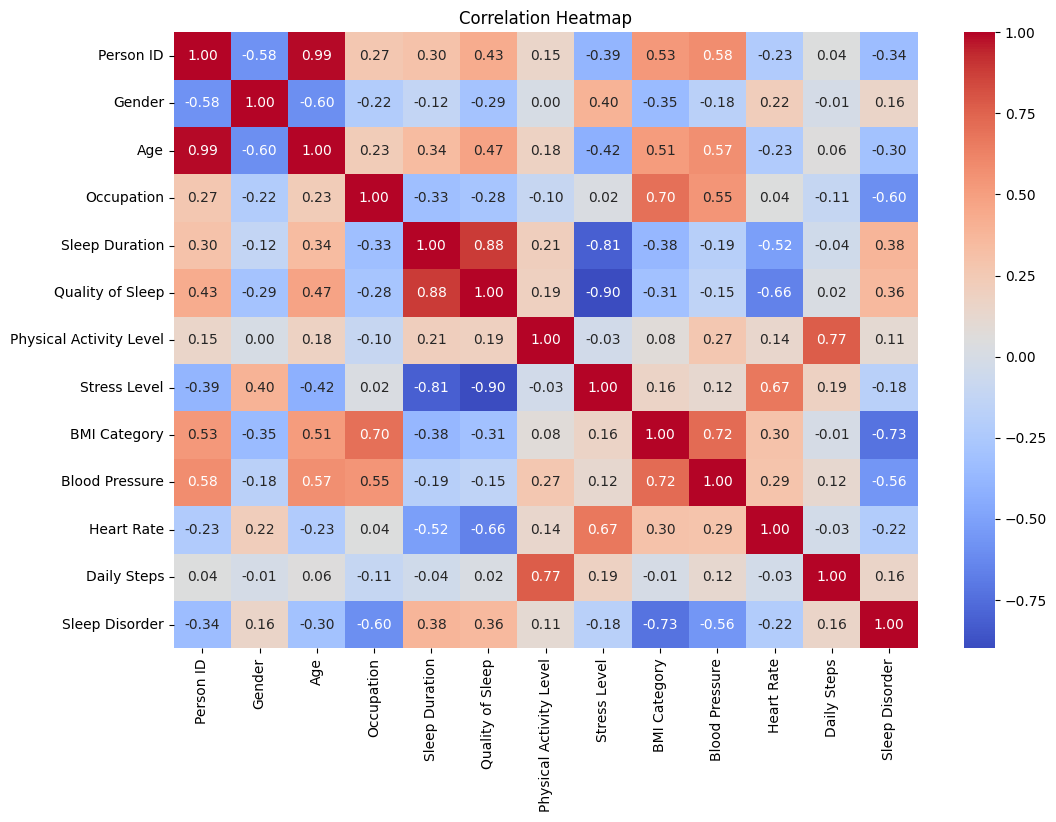

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Sleep Duration vs Quality of Sleep

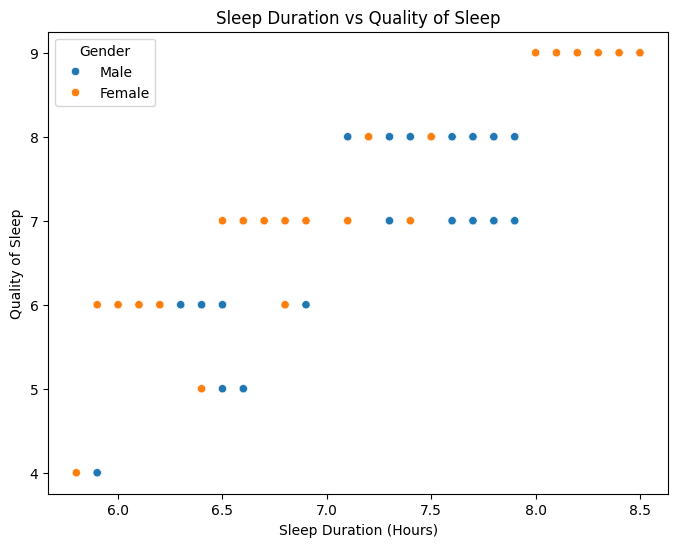

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Sleep Duration",
    y="Quality of Sleep",
    hue="Gender",
    data=df
)

plt.title("Sleep Duration vs Quality of Sleep")

plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Quality of Sleep")

plt.show()

MACHINE LEARNING

Select Features and Target

In [ ]:
X = df_encoded[[
    "Sleep Duration",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Age"
]]

y = df_encoded["Quality of Sleep"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (374, 6)
Target Shape: (374,)


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train the Linear Regression Model

In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


Make Predictions

In [ ]:
y_pred = lr_model.predict(X_test_scaled)
prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

prediction_df.head(10)

,Actual,Predicted
329,9,9.097642
33,6,5.442221
15,6,5.664686
325,9,9.097642
57,6,5.389682
239,6,6.226065
76,6,5.403527
119,8,7.793181
332,9,9.045104
126,8,7.642816


Evaluate the Model

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-" * 30)
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Model Evaluation
------------------------------
MAE  : 0.286
MSE  : 0.127
RMSE : 0.357
R²   : 0.916


Actual vs Predicted

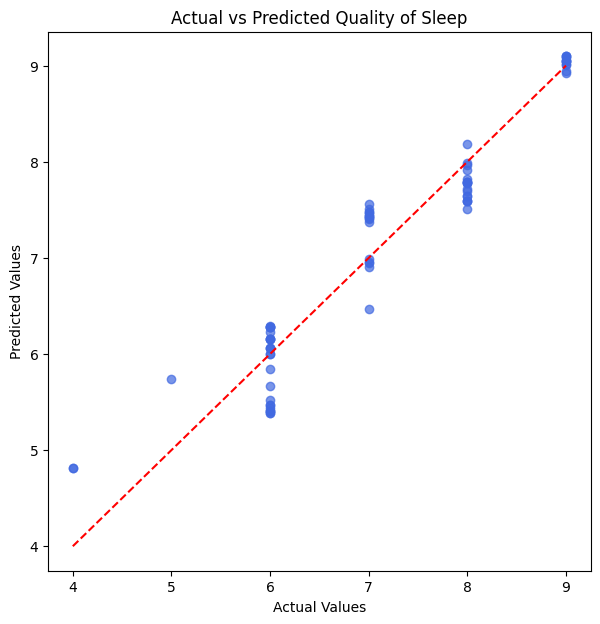

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, color="royalblue", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted Quality of Sleep")

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.show()

Feature Importance

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

importance["Absolute Coefficient"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

importance

,Feature,Coefficient,Absolute Coefficient
2,Stress Level,-0.568691,0.568691
0,Sleep Duration,0.522648,0.522648
4,Daily Steps,0.146216,0.146216
5,Age,0.118646,0.118646
3,Heart Rate,-0.084887,0.084887
1,Physical Activity Level,-0.012330,0.012330


Plot

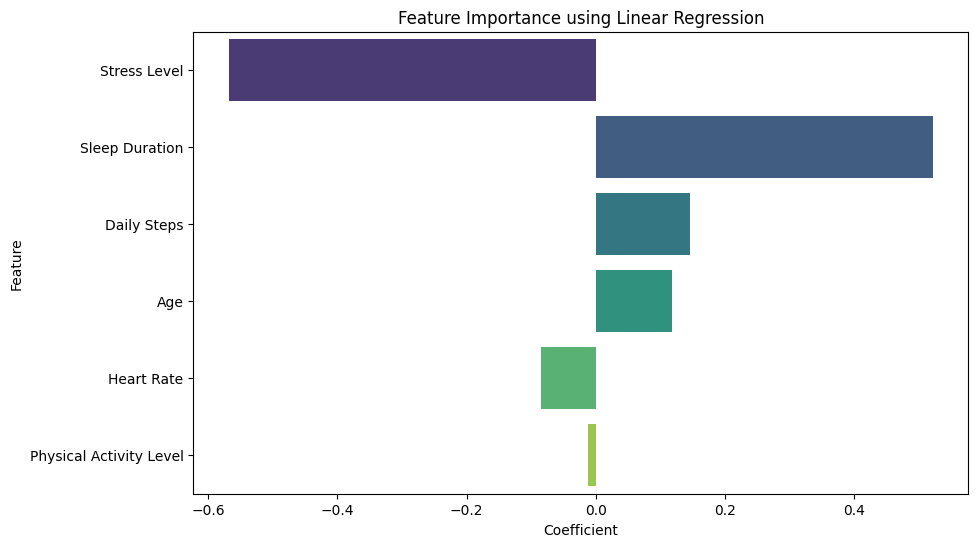

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Coefficient",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance using Linear Regression")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

Decision Tree Regressor

Train model

In [ ]:
from sklearn.model_selection import GridSearchCV

dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid={
        "max_depth":[3,5,7,10,None],
        "min_samples_split":[2,5,10],
        "min_samples_leaf":[1,2,4]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)

dt_grid.fit(X_train_scaled, y_train)

dt_model = dt_grid.best_estimator_



Make Predictions

In [ ]:
y_pred_dt = dt_model.predict(X_test_scaled)

print(dt_grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


Evaluate the Model

In [ ]:
dt_mae = mean_absolute_error(y_test,y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("-" * 30)
print(f"MAE  : {dt_mae:.3f}")
print(f"MSE  : {dt_mse:.3f}")
print(f"RMSE : {dt_rmse:.3f}")
print(f"R²   : {dt_r2:.3f}")

Decision Tree Results
------------------------------
MAE  : 0.000
MSE  : 0.000
RMSE : 0.000
R²   : 1.000


Actual vs Predicted

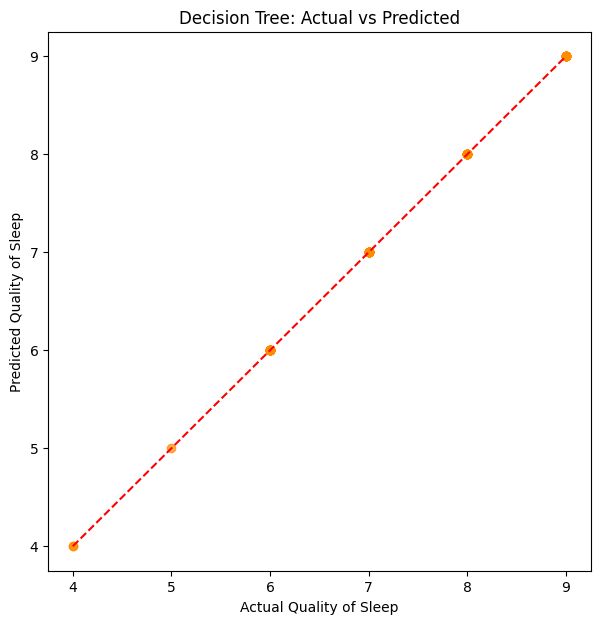

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
   y_pred_dt,
    color="darkorange",
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.title("Decision Tree: Actual vs Predicted")

plt.xlabel("Actual Quality of Sleep")

plt.ylabel("Predicted Quality of Sleep")

plt.show()

Feature Importance

In [ ]:
dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

dt_importance

,Feature,Importance
0,Sleep Duration,0.849309
2,Stress Level,0.089598
3,Heart Rate,0.028005
4,Daily Steps,0.016386
5,Age,0.014904
1,Physical Activity Level,0.001797


Plot

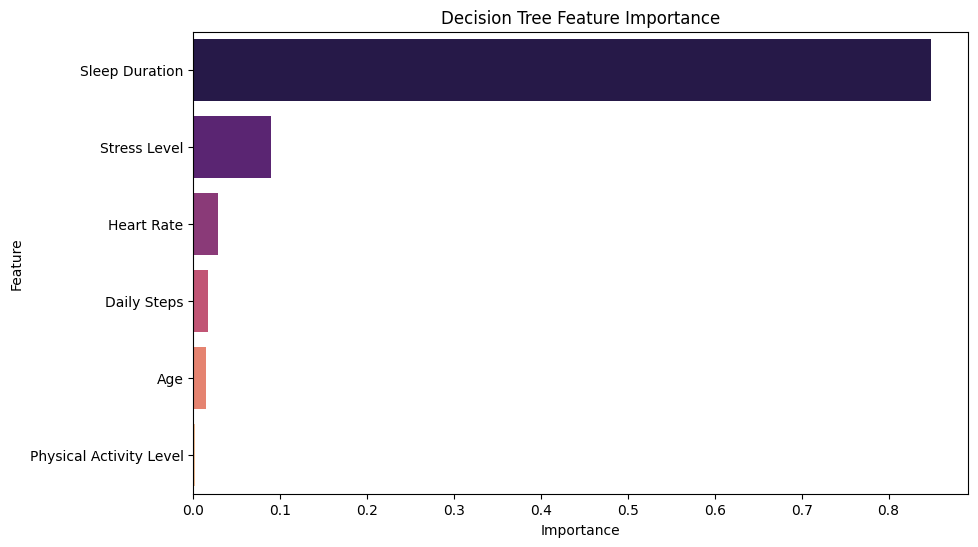

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=dt_importance,
    x="Importance",
    y="Feature",
    palette="magma"
)

plt.title("Decision Tree Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

Random Forest Regressor

Train

In [ ]:
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid={
        "n_estimators":[50,100,200],
        "max_depth":[3,5,7,10,None],
        "min_samples_split":[2,5,10]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

rf_model = rf_grid.best_estimator_


Predict

In [ ]:
y_pred_rf = rf_model.predict(X_test_scaled)

print(rf_grid.best_params_)

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


Evaluate

In [ ]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("-" * 30)
print(f"MAE  : {rf_mae:.3f}")
print(f"MSE  : {rf_mse:.3f}")
print(f"RMSE : {rf_rmse:.3f}")
print(f"R²   : {rf_r2:.3f}")

Random Forest Results
------------------------------
MAE  : 0.036
MSE  : 0.014
RMSE : 0.116
R²   : 0.991


Actual vs Predicted

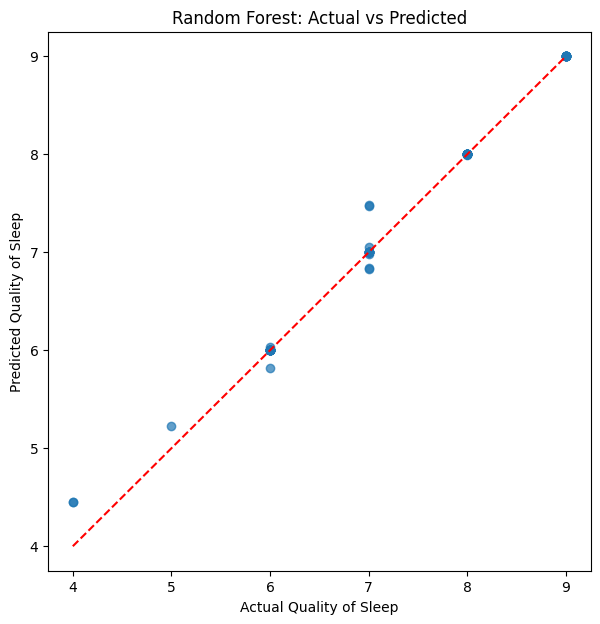

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Quality of Sleep")
plt.ylabel("Predicted Quality of Sleep")

plt.show()

Feature

In [ ]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
0,Sleep Duration,0.796307
2,Stress Level,0.123182
3,Heart Rate,0.038012
5,Age,0.027667
4,Daily Steps,0.012189
1,Physical Activity Level,0.002643


plot

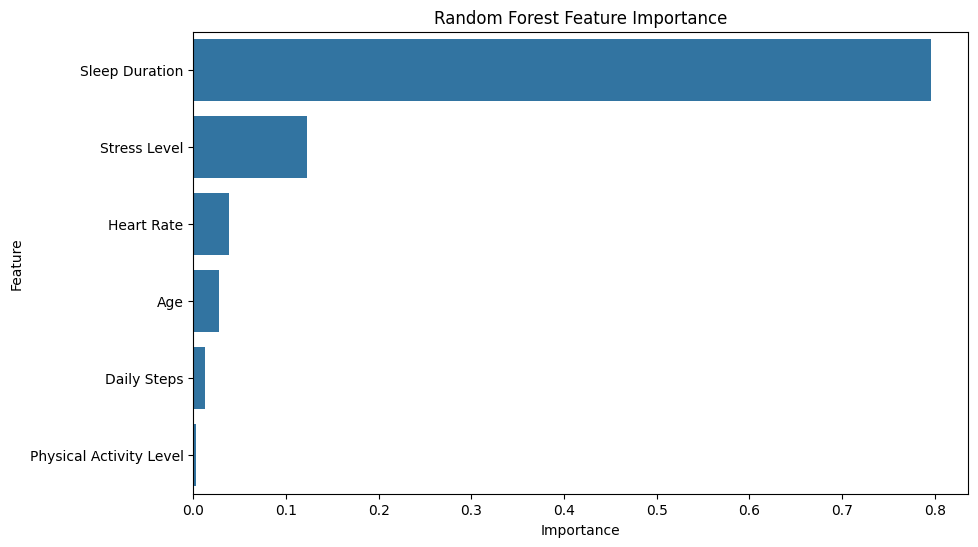

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Support Vector Regressor

Import and Train SVR

In [ ]:
svr_grid = GridSearchCV(
    estimator=SVR(),
    param_grid={
        "kernel":["linear","rbf"],
        "C":[0.1,1,10,100],
        "epsilon":[0.01,0.1,0.2]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)

svr_grid.fit(X_train_scaled, y_train)

svr_model = svr_grid.best_estimator_


Predict

In [ ]:
y_pred_svr = svr_model.predict(X_test_scaled)

print(svr_grid.best_params_)

{'C': 10, 'epsilon': 0.01, 'kernel': 'rbf'}


Evaluate

In [ ]:
svr_mae = mean_absolute_error(y_test, y_pred_svr)
svr_mse = mean_squared_error(y_test, y_pred_svr)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, y_pred_svr)

print("SVR Results")
print("-" * 30)
print(f"MAE  : {svr_mae:.3f}")
print(f"MSE  : {svr_mse:.3f}")
print(f"RMSE : {svr_rmse:.3f}")
print(f"R²   : {svr_r2:.3f}")

SVR Results
------------------------------
MAE  : 0.014
MSE  : 0.001
RMSE : 0.028
R²   : 0.999


Actual vs Predicted

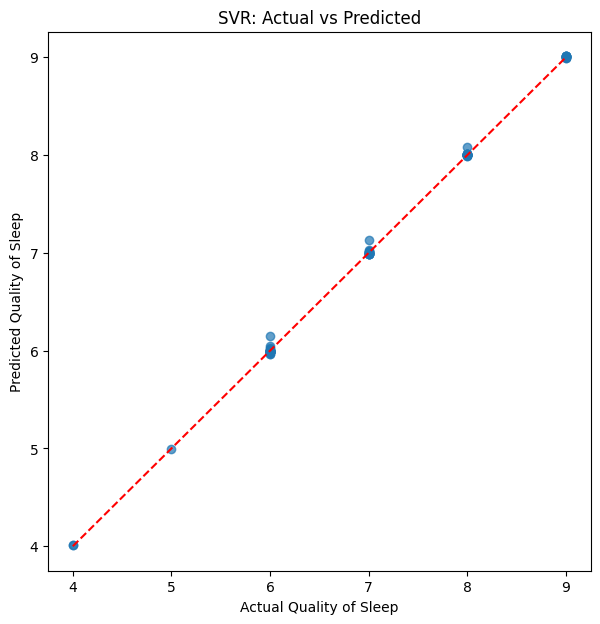

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_svr, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.title("SVR: Actual vs Predicted")
plt.xlabel("Actual Quality of Sleep")
plt.ylabel("Predicted Quality of Sleep")

plt.show()

XGBoost Regressor

In [ ]:
!pip install -q xgboost

Train

In [ ]:
xgb_grid = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_grid={
        "n_estimators":[50,100,200],
        "max_depth":[3,5,7],
        "learning_rate":[0.01,0.05,0.1]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)

xgb_model = xgb_grid.best_estimator_


Predict

In [ ]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

print(xgb_grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


Evaluate

In [ ]:
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("-" * 30)
print(f"MAE  : {xgb_mae:.3f}")
print(f"MSE  : {xgb_mse:.3f}")
print(f"RMSE : {xgb_rmse:.3f}")
print(f"R²   : {xgb_r2:.3f}")

XGBoost Results
------------------------------
MAE  : 0.019
MSE  : 0.003
RMSE : 0.059
R²   : 0.998


Actual vs Predicted

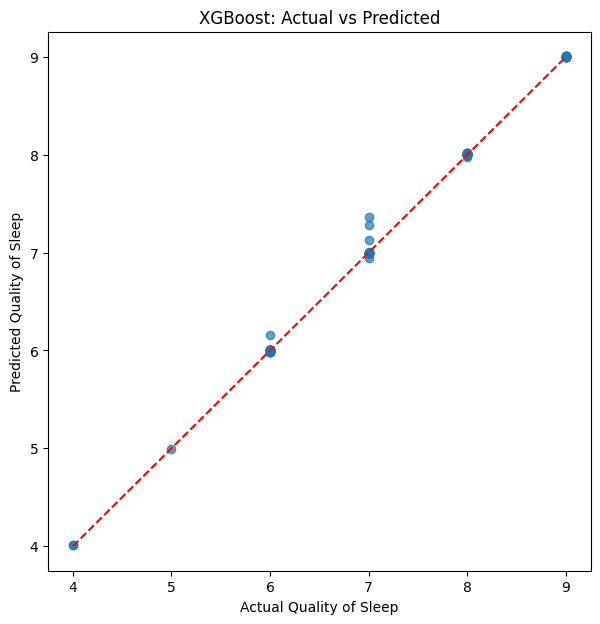

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_xgb, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Actual Quality of Sleep")
plt.ylabel("Predicted Quality of Sleep")

plt.show()

Feature

In [ ]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
0,Sleep Duration,0.666145
2,Stress Level,0.251497
3,Heart Rate,0.033427
5,Age,0.029058
4,Daily Steps,0.013710
1,Physical Activity Level,0.006164


plot

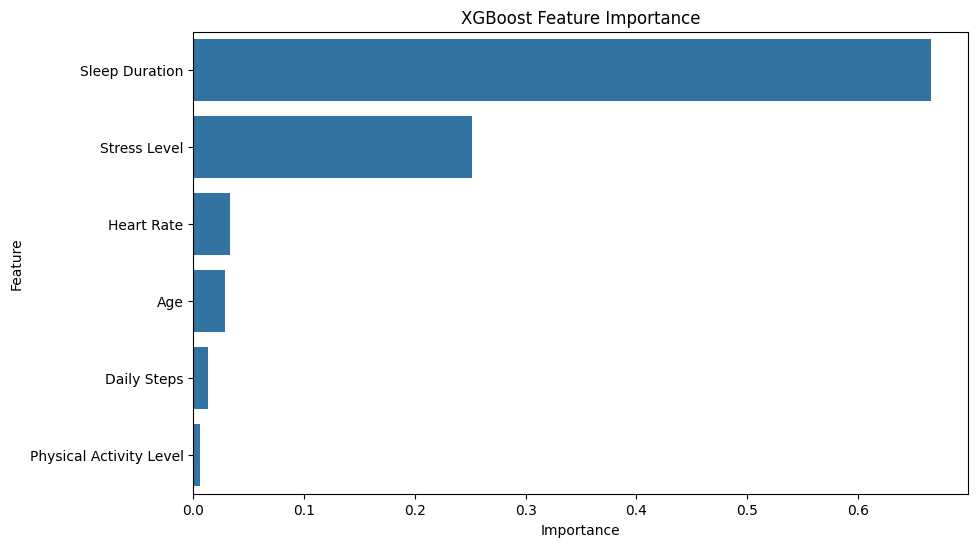

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Adjusted R Square

In [ ]:
def adjusted_r2_score(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

n = X_test_scaled.shape[0]
p = X_test_scaled.shape[1]

adj_r2 = adjusted_r2_score(r2, n, p)
dt_adj_r2 = adjusted_r2_score(dt_r2, n, p)
rf_adj_r2 = adjusted_r2_score(rf_r2, n, p)
svr_adj_r2 = adjusted_r2_score(svr_r2, n, p)
xgb_adj_r2 = adjusted_r2_score(xgb_r2, n, p)


Model Comparison

In [ ]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Support Vector Regressor",
        "XGBoost Regressor"
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae,
        svr_mae,
        xgb_mae
    ],
    "MSE": [
        mse,
        dt_mse,
        rf_mse,
        svr_mse,
        xgb_mse
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse,
        svr_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        r2,
        dt_r2,
        rf_r2,
        svr_r2,
        xgb_r2
    ],   # <-- comma added here

    "Adjusted R2": [
        adj_r2,
        dt_adj_r2,
        rf_adj_r2,
        svr_adj_r2,
        xgb_adj_r2
    ]
})

model_results = model_results.sort_values(by="R2 Score", ascending=False)

model_results

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
1,Decision Tree Regressor,0.000000,0.000000,0.000000,1.000000,1.000000
3,Support Vector Regressor,0.013895,0.000789,0.028098,0.999477,0.999431
4,XGBoost Regressor,0.018856,0.003448,0.058722,0.997714,0.997513
2,Random Forest Regressor,0.036333,0.013526,0.116303,0.991034,0.990243
0,Linear Regression,0.285640,0.127474,0.357035,0.915503,0.908048


In [ ]:
best_model = model_results.loc[model_results["R2 Score"].idxmax()]

best_model_name = best_model["Model"]
best_r2 = best_model["R2 Score"]
best_rmse = best_model["RMSE"]
best_mae = best_model["MAE"]

trained_models = {
    "Linear Regression": lr_model,
    "Decision Tree Regressor": dt_model,
    "Random Forest Regressor": rf_model,
    "Support Vector Regressor": svr_model,
    "XGBoost Regressor": xgb_model
}

best_trained_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Decision Tree Regressor


Residual Analysis for Best Regression Model

In [ ]:
y_pred_best = best_trained_model.predict(X_test_scaled)

residuals = y_test - y_pred_best

Residual vs Predicted Plot

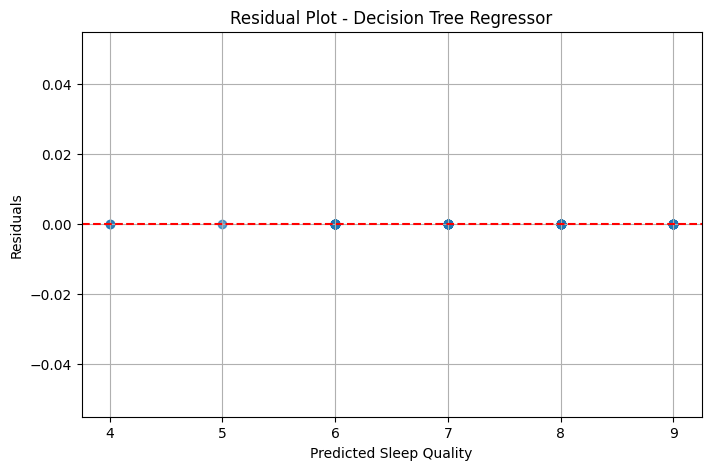

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals, alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Sleep Quality")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {best_model_name}")
plt.grid(True)
plt.show()

Distribution of Residuals

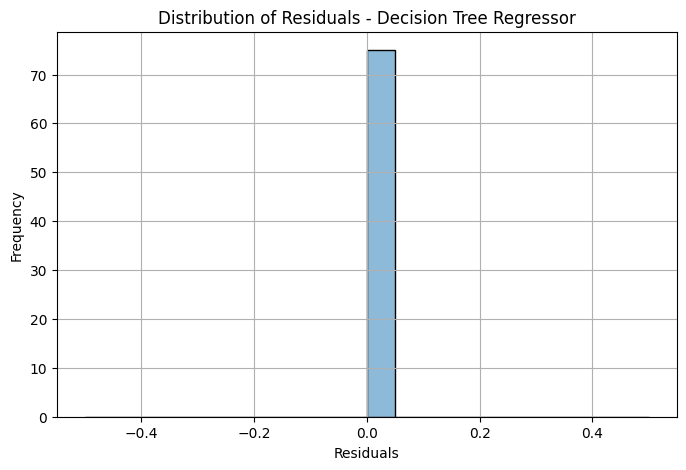

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=20)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title(f"Distribution of Residuals - {best_model_name}")
plt.grid(True)
plt.show()

Prediction Error Distribution

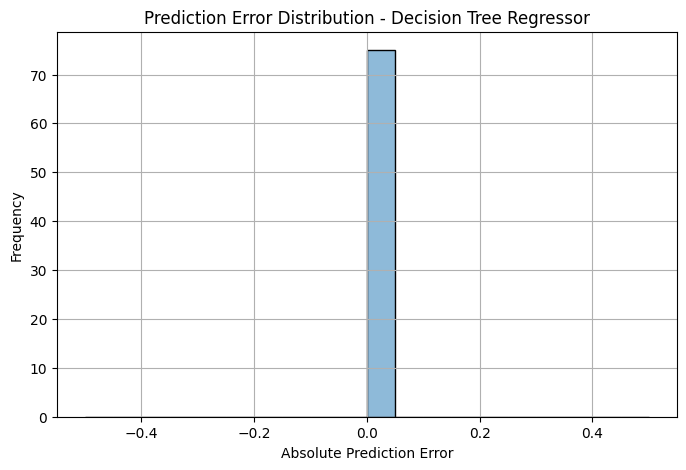

In [ ]:
prediction_errors = np.abs(residuals)

plt.figure(figsize=(8, 5))
sns.histplot(prediction_errors, kde=True, bins=20)

plt.xlabel("Absolute Prediction Error")
plt.ylabel("Frequency")
plt.title(f"Prediction Error Distribution - {best_model_name}")
plt.grid(True)
plt.show()

Bar Plot for R² Score

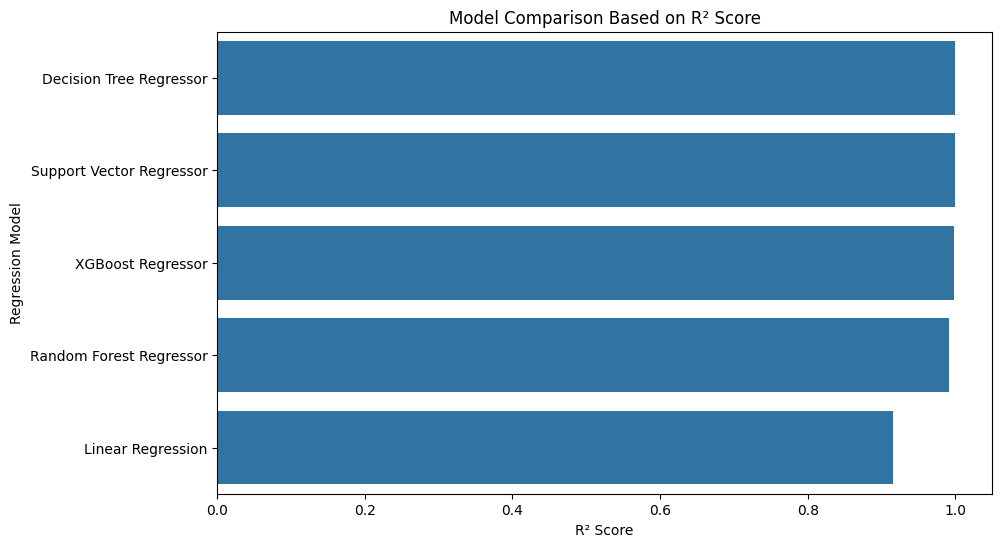

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=model_results,
    x="R2 Score",
    y="Model"
)

plt.title("Model Comparison Based on R² Score")
plt.xlabel("R² Score")
plt.ylabel("Regression Model")

plt.show()

K-Means Clustering

In [ ]:
cluster_features = df_encoded[[
    "Sleep Duration",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Age"
]]

Standardize the Features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_features)

Elbow Method

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_scaled)

    inertia.append(kmeans.inertia_)

Plot Elbow Curve

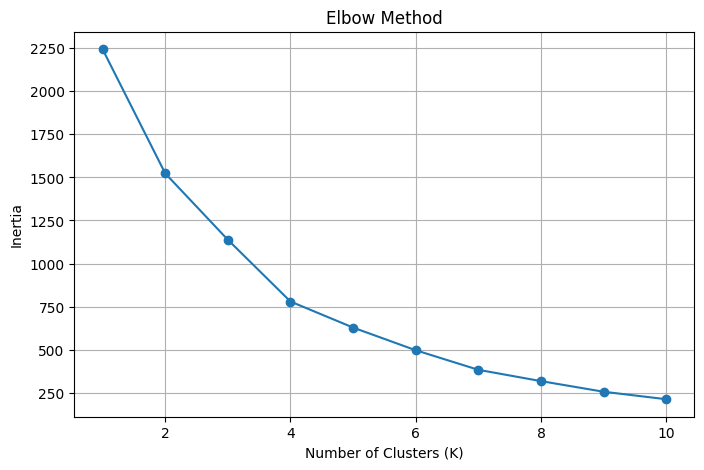

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

Apply K-Means

In [ ]:
# Optimal number of clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["SleepCluster"] = kmeans.fit_predict(cluster_scaled)

print("Cluster Centers:")
print(kmeans.cluster_centers_)

Cluster Centers:
[[ 0.26832447  0.34664481 -0.34339943 -0.45317022  0.31868754 -0.48243317]
 [-1.33220035  1.39711869  1.47559156  1.17047394  1.97007745  0.72574889]
 [-0.92255667 -0.87022147  0.94417704  0.92365016 -0.87749634 -0.44051798]
 [ 1.41347746 -0.25072898 -1.32899172 -0.86407676 -0.45936406  1.53300787]]


Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(cluster_scaled, df["SleepCluster"])

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.49


Cluster Visualization

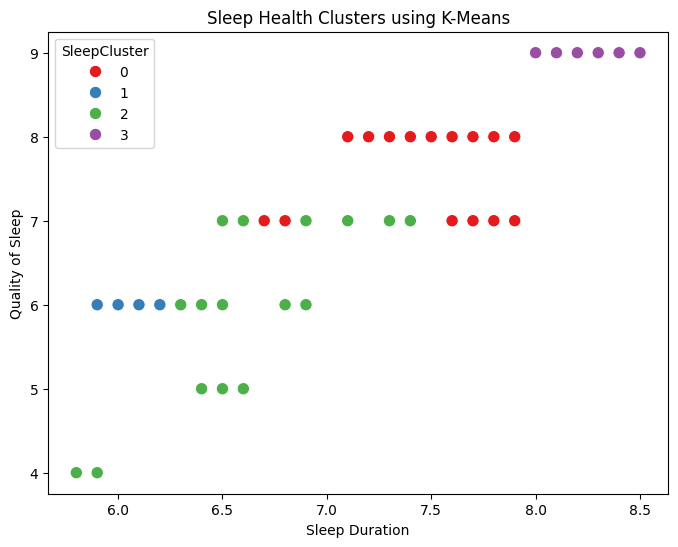

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Sleep Duration",
    y="Quality of Sleep",
    hue="SleepCluster",
    palette="Set1",
    s=80
)

plt.title("Sleep Health Clusters using K-Means")
plt.xlabel("Sleep Duration")
plt.ylabel("Quality of Sleep")

plt.show()

Cluster Summary

In [ ]:
cluster_summary = df.groupby("SleepCluster")[[
    "Sleep Duration",
    "Quality of Sleep",
    "Stress Level",
    "Physical Activity Level",
    "Heart Rate",
    "Daily Steps"
]].mean().round(2)

cluster_summary

,Sleep Duration,Quality of Sleep,Stress Level,Physical Activity Level,Heart Rate,Daily Steps
SleepCluster,,,,,,
0,7.35,7.66,4.78,66.38,68.29,7331.76
1,6.07,6.00,8.00,88.24,75.00,10000.00
2,6.40,6.07,7.06,41.07,73.98,5399.03
3,8.26,9.00,3.03,53.96,66.60,6074.63


Cross Validation

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Decision Tree Regressor": GridSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", DecisionTreeRegressor(random_state=42))
        ]),
        param_grid={
            "model__max_depth": [3, 5, 7, 10, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        },
        cv=cv,
        scoring="r2",
        n_jobs=-1
    ),

    "Random Forest Regressor": GridSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestRegressor(random_state=42))
        ]),
        param_grid={
            "model__n_estimators": [50, 100, 200],
            "model__max_depth": [3, 5, 7, 10, None],
            "model__min_samples_split": [2, 5, 10]
        },
        cv=cv,
        scoring="r2",
        n_jobs=-1
    ),

    "Support Vector Regressor": GridSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR())
        ]),
        param_grid={
            "model__kernel": ["linear", "rbf"],
            "model__C": [0.1, 1, 10, 100],
            "model__epsilon": [0.01, 0.1, 0.2]
        },
        cv=cv,
        scoring="r2",
        n_jobs=-1
    ),

    "XGBoost Regressor": GridSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", XGBRegressor(
                random_state=42,
                objective="reg:squarederror"
            ))
        ]),
        param_grid={
            "model__n_estimators": [50, 100, 200],
            "model__max_depth": [3, 5, 7],
            "model__learning_rate": [0.01, 0.05, 0.1]
        },
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )
}

In [ ]:
cv_results = []

for name, model in cv_models.items():
    model.fit(X, y)

    if isinstance(model, GridSearchCV):
        score = model.best_score_
        best_params = model.best_params_
    else:
        scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
        score = scores.mean()
        best_params = "Default parameters"

    cv_results.append({
        "Model": name,
        "Mean CV R2 Score": score,
        "Best Parameters": best_params
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,Mean CV R2 Score,Best Parameters
0,Linear Regression,0.902016,Default parameters
1,Decision Tree Regressor,0.979696,"{'model__max_depth': 10, 'model__min_samples_l..."
2,Random Forest Regressor,0.981702,"{'model__max_depth': 7, 'model__min_samples_sp..."
3,Support Vector Regressor,0.984332,"{'model__C': 10, 'model__epsilon': 0.01, 'mode..."
4,XGBoost Regressor,0.983386,"{'model__learning_rate': 0.1, 'model__max_dept..."


Find the best model based on R² Score


SHAP

In [ ]:
!pip install -q shap
import shap
import pandas as pd
import numpy as np

In [ ]:
# Create scaled DataFrames for SVR
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

In [ ]:
# SHAP Explainer based on best model type

if best_model_name == "Support Vector Regressor":
    background = shap.sample(X_train_scaled_df, 100, random_state=42)

    explainer = shap.KernelExplainer(
        best_trained_model.predict,
        background
    )

    shap_values_array = explainer.shap_values(X_test_scaled_df.iloc[:50])

    shap_values = shap.Explanation(
        values=shap_values_array,
        base_values=np.repeat(explainer.expected_value, 50),
        data=X_test_scaled_df.iloc[:50].values,
        feature_names=X.columns
    )

    shap_data = X_test_scaled_df.iloc[:50]

else:
    explainer = shap.Explainer(best_trained_model, X_train)
    shap_values = explainer(X_test)
    shap_data = X_test

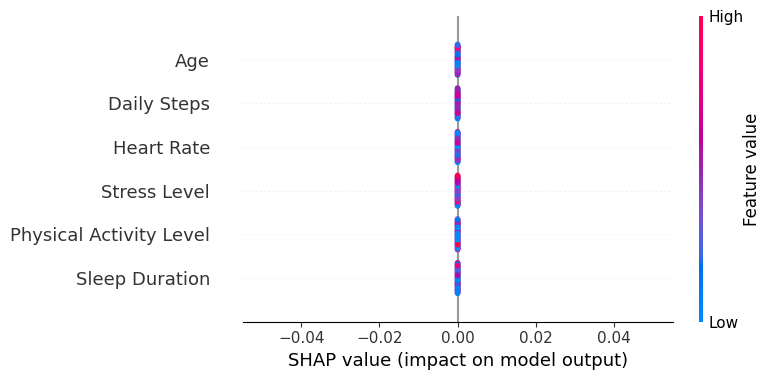

In [ ]:
shap.summary_plot(shap_values.values, shap_data, feature_names=X.columns)

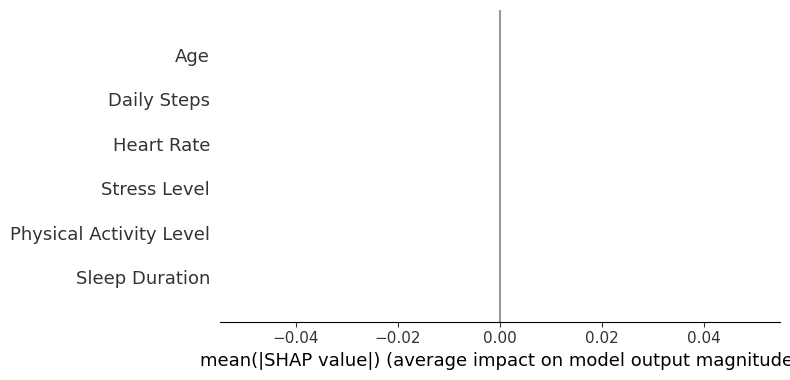

In [ ]:
shap.summary_plot(
    shap_values.values,
    shap_data,
    feature_names=X.columns,
    plot_type="bar"
)

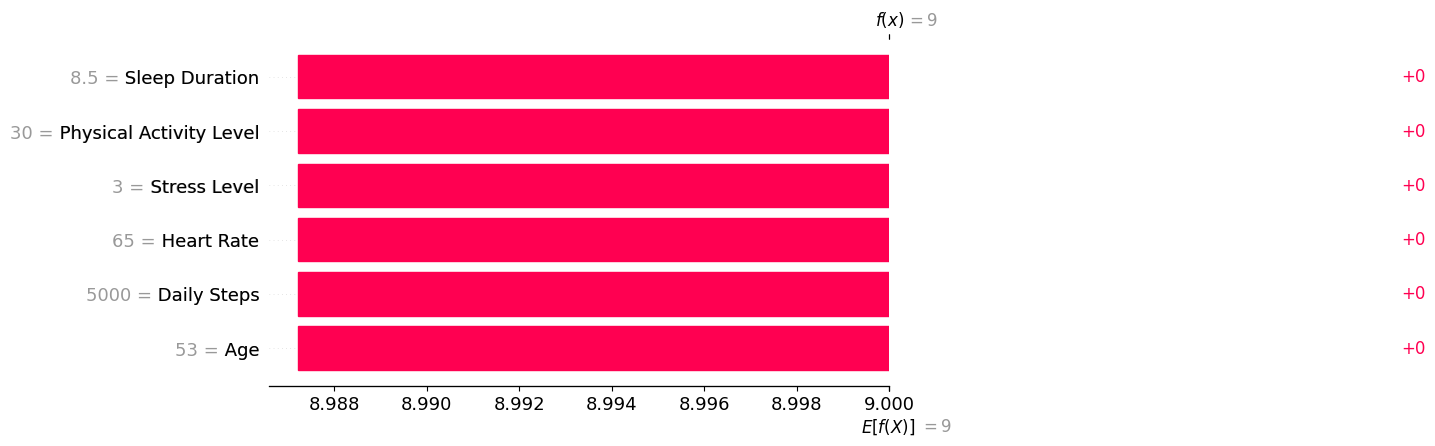

In [ ]:
sample_index = 0

shap.plots.waterfall(shap_values[sample_index])

LLM

In [ ]:
!pip install -q google-generativeai

In [ ]:
from getpass import getpass
import google.generativeai as genai

In [ ]:
api_key = getpass("Enter your Gemini API Key: ")


Enter your Gemini API Key: ··········


In [ ]:
genai.configure(api_key=api_key)

In [ ]:
model = genai.GenerativeModel("gemini-2.5-flash")

In [ ]:
sample = X_test.iloc[0]

if best_model_name == "Support Vector Regressor":
    predicted_quality = best_trained_model.predict(X_test_scaled_df.iloc[[0]])[0]
else:
    predicted_quality = best_trained_model.predict(X_test.iloc[[0]])[0]

sample_index = sample.name
assigned_cluster = df.loc[sample_index, "SleepCluster"]

In [ ]:
sample_shap = shap_values[0]

feature_importance = sorted(
    zip(X.columns, sample_shap.values),
    key=lambda x: abs(x[1]),
    reverse=True
)

top_features = feature_importance[:5]

In [ ]:
shap_text = ""

for feature, value in top_features:
    shap_text += f"{feature}: {value:.3f}\n"

In [ ]:
prompt = f"""
Role:
You are an AI-powered Clinical Sleep Health Assistant developed to interpret
machine learning predictions generated from sleep and lifestyle data.

Project Context
-------------------------
A machine learning framework was developed to predict sleep quality and
identify sleep behavior patterns.

The prediction shown below was generated by the BEST performing regression model.

Best Performing Regression Model:
{best_model_name}

Model Performance
-------------------------
R² Score : {best_r2:.3f}
RMSE : {best_rmse:.3f}
MAE : {best_mae:.3f}

Machine Learning Prediction
-------------------------
Predicted Sleep Quality : {predicted_quality:.2f}/10
Assigned Sleep Cluster : Cluster {assigned_cluster}

User Sleep & Lifestyle Information
-------------------------
Age : {sample['Age']}
Sleep Duration : {sample['Sleep Duration']} hours
Physical Activity Level : {sample['Physical Activity Level']}
Stress Level : {sample['Stress Level']}
Heart Rate : {sample['Heart Rate']} bpm
Daily Steps : {sample['Daily Steps']}

Generate a structured report using the following headings exactly.

1. Sleep Health Summary

2. Interpretation of Sleep Cluster

3. Factors Influencing the Prediction

4. Personalized Recommendations
Provide 4 evidence-based recommendations.

5. Lifestyle Suggestions

6. Conclusion

7. Disclaimer

Requirements

• Explain the prediction in language understandable by non-medical users.

• Base every statement ONLY on the supplied machine learning prediction and user features.

• Do NOT diagnose diseases.

• Do NOT prescribe medications.

• Do NOT invent missing information.

• Mention that the interpretation is based on the prediction generated by the best-performing machine learning model.

• Keep the response between 250 and 350 words.

• Use a professional, scientific, and supportive tone.
"""

In [ ]:
response = model.generate_content(prompt)

print(response.text)

Here is a structured report based on your sleep and lifestyle information:

---

### AI-Powered Clinical Sleep Health Report

**1. Sleep Health Summary**
Based on the prediction generated by our best-performing machine learning model, a Decision Tree Regressor, your predicted sleep quality is excellent at 9.00 out of 10. You have been assigned to Sleep Cluster 3, indicating a profile associated with positive sleep health attributes. This assessment is derived from your provided sleep and lifestyle data.

**2. Interpretation of Sleep Cluster**
Your assignment to Cluster 3 suggests that your current sleep and lifestyle patterns align with individuals who typically experience high sleep quality. This cluster likely represents a profile characterized by sufficient sleep duration, balanced physical activity, and effective stress management, all contributing to favorable sleep outcomes based on the characteristics observed in your data.

**3. Factors Influencing the Prediction**
The excellen